In [3]:
#pip install overturemaps geopandas pandas shapely pyarrow

In [1]:
import geopandas as gpd
from overturemaps import core
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

In [2]:
# Центр Анкары (примерный bbox)
bbox_center = (32.83, 39.90, 32.92, 39.96)  # xmin, ymin, xmax, ymax

gdf = core.geodataframe("building", bbox=bbox_center)
print("Downloaded buildings:", len(gdf))
print("Columns:", list(gdf.columns))

gdf = gdf.copy()
gdf["floors"] = pd.to_numeric(gdf["num_floors"], errors="coerce") if "num_floors" in gdf.columns else pd.NA
gdf["h"] = pd.to_numeric(gdf["height"], errors="coerce") if "height" in gdf.columns else pd.NA

total = len(gdf)
share_f = 100 * gdf["floors"].notna().mean() if total else 0
share_h = 100 * gdf["h"].notna().mean() if total else 0
print(f"Total: {total}")
print(f"Share with num_floors: {share_f:.2f}%")
print(f"Share with height: {share_h:.2f}%")

Downloaded buildings: 34409
Columns: ['id', 'geometry', 'bbox', 'version', 'sources', 'level', 'subtype', 'class', 'height', 'names', 'has_parts', 'is_underground', 'num_floors', 'num_floors_underground', 'min_height', 'min_floor', 'facade_color', 'facade_material', 'roof_material', 'roof_shape', 'roof_direction', 'roof_orientation', 'roof_color', 'roof_height']
Total: 34409
Share with num_floors: 3.43%
Share with height: 1.15%


In [3]:
gdf = gdf.set_crs("EPSG:4326", allow_override=True)

In [4]:
gdf_shp = gdf[["id", "num_floors", "height", "geometry"]].copy()

In [5]:
out_path = "ankara_center_overture_clean.shp"
gdf_shp.to_file(out_path, driver="ESRI Shapefile")
print("Saved:", out_path)

Saved: ankara_center_overture_clean.shp


[None, None, None, None, None, None]

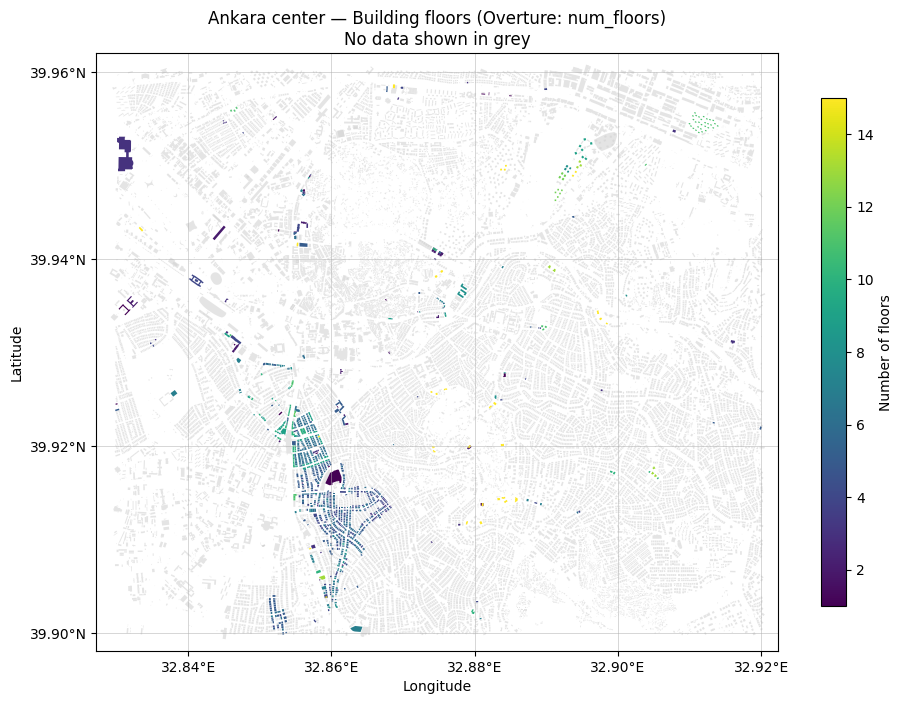

In [7]:
minx, miny, maxx, maxy = gdf.total_bounds
dx = maxx - minx
dy = maxy - miny

padx = dx * 0.02
pady = dy * 0.02
xmin, xmax = minx - padx, maxx + padx
ymin, ymax = miny - pady, maxy + pady

span = max(dx, dy)
if span > 0.3:
    step = 0.1
elif span > 0.12:
    step = 0.05
elif span > 0.06:
    step = 0.02
else:
    step = 0.01

def fmt_lon(x, pos=None):
    return f"{x:.2f}°E"
def fmt_lat(y, pos=None):
    return f"{y:.2f}°N"

fig, ax = plt.subplots(figsize=(11, 11))

gdf[gdf["floors"].isna()].plot(
    ax=ax,
    color="lightgrey",
    linewidth=0,
    alpha=0.6)

gdf_valid = gdf[gdf["floors"].notna()]
plot = gdf_valid.plot(
    ax=ax,
    column="floors",
    legend=True,
    vmin = 1,
    vmax = 15,
    linewidth=0,
    legend_kwds={"label": "Number of floors", "shrink": 0.6})


ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.xaxis.set_major_locator(MultipleLocator(step))
ax.yaxis.set_major_locator(MultipleLocator(step))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))

ax.grid(True, which="major", linewidth=0.6, alpha=0.6)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Ankara center — Building floors (Overture: num_floors)\nNo data shown in grey")


plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.setp(ax.get_yticklabels(), rotation=0)